# **Aymara–Spanish NMT: Paper Analysis**

## Raw Data

In [1]:
import json
import pandas as pd

### Bible

In [2]:
for bible_id, lang in [(293, "aym"), (2250, "aym"), (146, "spa"), (4278, "spa")]:

    with open(f"data/raw/bible/{lang}/{bible_id}.json", "r", encoding="utf-8") as file:
        data = json.load(file)

    num_verses = len(data)

    print(f"Number of verses for Bible Id = {bible_id} (lang: {lang}) --> {num_verses}")

Number of verses for Bible Id = 293 (lang: aym) --> 30816
Number of verses for Bible Id = 2250 (lang: aym) --> 30700
Number of verses for Bible Id = 146 (lang: spa) --> 31104
Number of verses for Bible Id = 4278 (lang: spa) --> 30720


### Book

In [3]:
df_book = pd.read_csv("data/raw/book/book.tsv", sep="\t")
print(f"Number of book raw pairs --> {len(df_book)}")

Number of book raw pairs --> 1907


## Clean Data

### Bible

In [4]:
df_clean_bible = pd.read_csv("data/clean/verses_aligned_clean.tsv", sep="\t")
print(f"Number of pairs in clean biblical corpus --> {len(df_clean_bible)}")

Number of pairs in clean biblical corpus --> 120904


In [5]:
for elem in ["train", "val", "test"]:
    df_set = pd.read_csv(f"data/splits/{elem}_bible.tsv", sep="\t")
    print(f"Number of pairs for biblical [{elem}] split --> {len(df_set)}")

Number of pairs for biblical [train] split --> 108823
Number of pairs for biblical [val] split --> 6048
Number of pairs for biblical [test] split --> 6033


### Book

In [6]:
df_clean_book = pd.read_csv("data/clean/book_clean.tsv", sep="\t")
print(f"Number of pairs in clean book corpus --> {len(df_clean_book)}")

Number of pairs in clean book corpus --> 1618


In [7]:
for elem in ["train", "val", "test"]:
    df_set = pd.read_csv(f"data/splits/{elem}_dialogue.tsv", sep="\t")
    print(f"Number of pairs for conversational [{elem}] split --> {len(df_set)}")

Number of pairs for conversational [train] split --> 1132
Number of pairs for conversational [val] split --> 242
Number of pairs for conversational [test] split --> 244


## Number of Words and Tokens of Clean Data

In [8]:
import pandas as pd

### Bible

In [9]:
train_bible = pd.read_csv("data/tokenized/train_bible_tokenized.tsv", sep="\t")
print(f"Number of pairs in train set: {len(train_bible)}")

Number of pairs in train set: 108823


In [10]:
# Number of words
train_bible["aym_num_words"] = train_bible["aym_text"].astype(str).str.split().str.len()
train_bible["spa_num_words"] = train_bible["spa_text"].astype(str).str.split().str.len()

# Number of tokens
train_bible["aym_num_tokens"] = train_bible["aym_ids"].astype(str).str.split().str.len()
train_bible["spa_num_tokens"] = train_bible["spa_ids"].astype(str).str.split().str.len()

In [11]:
cols = ["aym_num_words", "spa_num_words", "aym_num_tokens", "spa_num_tokens"]
train_bible[cols].describe()

,aym_num_words,spa_num_words,aym_num_tokens,spa_num_tokens
count,108823.000000,108823.000000,108823.000000,108823.000000
mean,15.980620,23.664878,35.751376,34.721042
std,7.309407,10.376614,14.918544,13.809843
min,2.000000,2.000000,5.000000,4.000000
25%,10.000000,16.000000,24.000000,24.000000
50%,15.000000,22.000000,33.000000,32.000000
75%,20.000000,30.000000,45.000000,43.000000
max,58.000000,70.000000,148.000000,105.000000


In [12]:
percentiles = train_bible[cols].quantile([0.9998, 0.9999])
print(percentiles)

        aym_num_words  spa_num_words  aym_num_tokens  spa_num_tokens
0.9998           50.0           67.0        108.0000            97.0
0.9999           53.0           69.0        114.2356           100.0


### Book

In [13]:
train_book = pd.read_csv("data/tokenized/train_dialogue_tokenized.tsv", sep="\t")
print(f"Number of pairs in train set: {len(train_book)}")

Number of pairs in train set: 1132


In [14]:
# Number of words
train_book["aym_num_words"] = train_book["aym_text"].astype(str).str.split().str.len()
train_book["spa_num_words"] = train_book["spa_text"].astype(str).str.split().str.len()

# Number of tokens
train_book["aym_num_tokens"] = train_book["aym_ids"].astype(str).str.split().str.len()
train_book["spa_num_tokens"] = train_book["spa_ids"].astype(str).str.split().str.len()

In [15]:
cols = ["aym_num_words", "spa_num_words", "aym_num_tokens", "spa_num_tokens"]
train_book[cols].describe()

,aym_num_words,spa_num_words,aym_num_tokens,spa_num_tokens
count,1132.000000,1132.00000,1132.000000,1132.000000
mean,3.657244,5.35689,11.140459,10.801237
std,1.806025,2.55303,5.050818,4.622656
min,1.000000,1.00000,3.000000,3.000000
25%,3.000000,4.00000,8.000000,8.000000
50%,3.000000,5.00000,10.000000,10.000000
75%,4.000000,7.00000,13.000000,13.000000
max,16.000000,22.00000,53.000000,46.000000


In [16]:
percentiles = train_book[cols].quantile([0.9998, 0.9999])
print(percentiles)

        aym_num_words  spa_num_words  aym_num_tokens  spa_num_tokens
0.9998        15.7738        21.5476         52.3214         45.3214
0.9999        15.8869        21.7738         52.6607         45.6607


## 4. Model Parameters

In [17]:
from pathlib import Path
import pandas as pd
import sentencepiece as spm

from src.models.transformer import TranslationTransformer
from src.utils.config import load_config
from src.utils.model_parameters import count_parameters

In [18]:
cfg = load_config("config.yaml")

tokenizer_path = Path(cfg["tokenizer_dir"]) / "SentencePiece.model"

sp = spm.SentencePieceProcessor()
sp.load(str(tokenizer_path))

vocab_size = sp.vocab_size()
pad_id = sp.pad_id()

print(f"Vocabulary size: {vocab_size:,}")

Vocabulary size: 8,000


In [19]:
architectures = [(4, 4), (6, 2), (2, 6)]

results = []

for encoder_layers, decoder_layers in architectures:

    model = TranslationTransformer(
        vocab_size=vocab_size,
        d_model=cfg["d_model"],
        n_heads=cfg["n_heads"],
        num_encoder_layers=encoder_layers,
        num_decoder_layers=decoder_layers,
        dim_feedforward=cfg["dim_feedforward"],
        dropout=cfg["dropout"],
        pad_id=pad_id
    )

    parameter_count = count_parameters(model)

    results.append({
        "architecture": f"{encoder_layers}E-{decoder_layers}D",
        "encoder_layers": encoder_layers,
        "decoder_layers": decoder_layers,
        **parameter_count
    })

params_df = pd.DataFrame(results)

print(params_df)

  architecture  encoder_layers  decoder_layers  total_parameters  \
0        4E-4D               4               4           9421824   
1        6E-2D               6               2           8894464   
2        2E-6D               2               6           9949184   

   trainable_parameters  
0               9421824  
1               8894464  
2               9949184  


In [20]:
reference_params = params_df.loc[params_df["architecture"] == "4E-4D", "total_parameters"].iloc[0]

params_df["difference_vs_4E4D"] = params_df["total_parameters"] - reference_params

params_df["difference_vs_4E4D_pct"] = params_df["difference_vs_4E4D"] / reference_params * 100

params_df

,architecture,encoder_layers,decoder_layers,total_parameters,trainable_parameters,difference_vs_4E4D,difference_vs_4E4D_pct
0,4E-4D,4,4,9421824,9421824,0,0.000000
1,6E-2D,6,2,8894464,8894464,-527360,-5.597218
2,2E-6D,2,6,9949184,9949184,527360,5.597218


## Results

In [21]:
from src.utils.results_analysis import load_test_results, summarize_test_results, generate_latex_table, plot_architecture_chrf
import matplotlib.pyplot as plt

In [22]:
results_df = load_test_results("results")

results_df.head()

,seed,src,tgt,direction,encoder_layers,decoder_layers,architecture,stage,domain,test_pairs,BLEU,chrF++,best_checkpoint_epoch,total_execution_time,file
0,111,aym,spa,aym_to_spa,2,6,2E-6D,Fine-tuned,Biblical,6033,6.407262,23.970490,26,4.169824,finetuned_test_metrics_aym_to_spa_Enc2_Dec6_Se...
1,111,aym,spa,aym_to_spa,2,6,2E-6D,Fine-tuned,Conversational,244,37.323008,59.184574,26,4.169824,finetuned_test_metrics_aym_to_spa_Enc2_Dec6_Se...
2,222,aym,spa,aym_to_spa,2,6,2E-6D,Fine-tuned,Biblical,6033,6.785946,24.538479,28,4.120092,finetuned_test_metrics_aym_to_spa_Enc2_Dec6_Se...
3,222,aym,spa,aym_to_spa,2,6,2E-6D,Fine-tuned,Conversational,244,38.051097,60.058753,28,4.120092,finetuned_test_metrics_aym_to_spa_Enc2_Dec6_Se...
4,333,aym,spa,aym_to_spa,2,6,2E-6D,Fine-tuned,Biblical,6033,6.989764,24.901109,24,4.064216,finetuned_test_metrics_aym_to_spa_Enc2_Dec6_Se...


In [23]:
summary_df = summarize_test_results(results_df)

summary_df

,direction,architecture,stage,domain,n_seeds,BLEU_mean,BLEU_sd,chrF_mean,chrF_sd
0,aym_to_spa,2E-6D,Base,Biblical,3,22.022725,0.058174,42.722764,0.106490
1,aym_to_spa,2E-6D,Base,Conversational,3,3.224468,0.176048,23.532945,0.505078
2,aym_to_spa,2E-6D,Fine-tuned,Biblical,3,6.727657,0.295593,24.470026,0.469071
3,aym_to_spa,2E-6D,Fine-tuned,Conversational,3,37.368439,0.661114,59.459444,0.519609
4,aym_to_spa,4E-4D,Base,Biblical,3,22.307353,0.058527,42.958373,0.044112
5,aym_to_spa,4E-4D,Base,Conversational,3,3.035817,0.400060,23.394277,0.416095
6,aym_to_spa,4E-4D,Fine-tuned,Biblical,3,6.689338,0.193807,24.241854,0.300549
7,aym_to_spa,4E-4D,Fine-tuned,Conversational,3,38.201366,2.315480,59.346411,1.525473
8,aym_to_spa,6E-2D,Base,Biblical,3,21.426941,0.074107,42.066031,0.131258
9,aym_to_spa,6E-2D,Base,Conversational,3,3.724634,0.089930,22.741161,0.316407


In [24]:
latex_table = generate_latex_table(summary_df)

print(latex_table)

\begin{table}[t]
    \centering
    \caption{Translation performance for different encoder--decoder depth allocations on biblical and conversational test sets before and after fine-tuning. Results are reported as mean $\pm$ standard deviation over three random seeds.}
    \label{tab:nmt_experimental_results}
    \scriptsize
    \setlength{\tabcolsep}{3.2pt}
    \renewcommand{\arraystretch}{1.15}
    \begin{tabular}{llcccccccc}
        \hline
        \multirow{3}{*}{\textbf{Direction}} & \multirow{3}{*}{\textbf{Architecture}} & \multicolumn{4}{c}{\textbf{Base Model}} & \multicolumn{4}{c}{\textbf{Fine-Tuned Model}} \\
        \cline{3-10}
        & & \multicolumn{2}{c}{\textbf{Biblical}} & \multicolumn{2}{c}{\textbf{Conversational}} & \multicolumn{2}{c}{\textbf{Biblical}} & \multicolumn{2}{c}{\textbf{Conversational}} \\
        \cline{3-10}
        & & \textbf{BLEU} & \textbf{chrF++} & \textbf{BLEU} & \textbf{chrF++} & \textbf{BLEU} & \textbf{chrF++} & \textbf{BLEU} & \textbf{chrF++} \\


# **4. Plots**

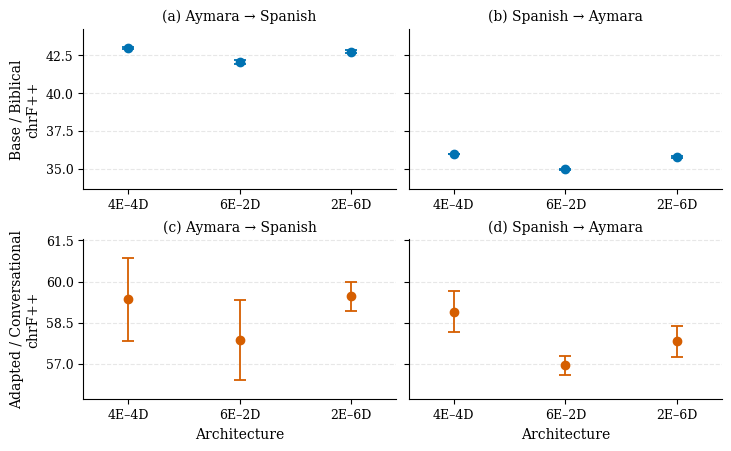

In [25]:
fig, axes = plot_architecture_chrf(
    summary_df,
    output_dir="plots",
)

plt.show()